# Régression logistique

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 11h49

# Préambule

## Message du jour

![](https://cdn.theatlantic.com/thumbor/e3cWq_N5d7ra9OaF0EH0Qi4yH4E=/0x0:2000x1125/1952x1098/media/img/mt/2025/09/AIA_S2_Ep_9/original.jpg)

[AI and the Rise of Techno-Fascism in the United
States](https://www.theatlantic.com/podcasts/archive/2025/09/ai-and-the-fight-between-democracy-and-autocracy/684095/)
par Gary Kasparov, The Atlantic, 2025-09-05. (31m 13s)

Un podcast de 30 minutes où Garry Kasparov est rejoint par le
scientifique cognitif Gary Marcus.

[Garry Kasparov](https://www.kasparov.com) (né en 1963) est un grand
maître d’échecs russe et ancien champion du monde, largement considéré
comme l’un des plus grands joueurs de l’histoire. Il a occupé le premier
rang mondial pendant près de deux décennies et est également connu pour
ses matchs contre Deep Blue d’IBM ainsi que pour son activisme politique
et ses écrits ultérieurs.

[Gary Marcus](http://garymarcus.com/) (né en 1965) est un scientifique
cognitif américain, auteur et entrepreneur. Il est connu pour ses
critiques de l’apprentissage profond, ses travaux sur l’acquisition du
langage et le développement cognitif, et pour avoir fondé plusieurs
startups en intelligence artificielle.

> Kasparov et Marcus s’accordent à dire que l’IA est un outil—ni
> intrinsèquement utopique ni dystopique—and que les véritables risques
> proviennent de la manière dont elle est utilisée et par qui. Marcus
> souligne que les systèmes d’IA actuels manquent encore de véritable
> compréhension; ils fonctionnent par reconnaissance de motifs sur de
> vastes ensembles de données, et non par la compréhension de règles ou
> de concepts, ce qui entraîne des problèmes d’alignement : les machines
> font fréquemment des erreurs ou agissent de manière imprévue. Une
> préoccupation majeure est la manière dont l’IA amplifie la tromperie
> politique, la surveillance et la manipulation de l’information—des
> outils prisés par les intérêts autocratiques ou oligarchiques. Du côté
> positif, ils soutiennent que nous ne sommes pas impuissants : les
> sociétés démocratiques ont encore des leviers—réglementation légale,
> action de masse, résistance, insistance sur la responsabilité—et
> pourraient encore orienter l’IA pour qu’elle profite à la démocratie
> plutôt que de la saper. Le chemin par défaut est dangereux, mais avec
> une volonté politique, il n’est pas nécessaire de glisser
> irréversiblement vers le techno-fascisme. (Résumé généré par ChatGPT 5
> le 2025-09-16)

## Objectifs d’apprentissage

- **Différencier** entre les paradigmes de classification binaire et de
  classification multi-classes.
- **Décrire** une méthodologie pour convertir des problèmes de
  classification multi-classes en tâches de classification binaire.
- **Implémenter** un algorithme de régression logistique, en se
  concentrant sur son application aux problèmes de classification.

# Tâches de classification

## Définitions

- La **classification binaire** est une tâche d’apprentissage supervisé
  dont l’objectif est de catégoriser des instances (exemples) en **deux
  classes distinctes**.

- Une tâche de **classification multi-classes** est un type de problème
  d’apprentissage supervisé où l’objectif est de catégoriser des
  instances en **trois classes distinctes ou plus**.

**Attention** : La **classification multi-classes** ne doit pas être
confondue avec la **classification multi-étiquettes**, qui permet à une
instance d’être associée à plusieurs classes. Les algorithmes conçus
pour traiter ces tâches diffèrent de manière significative.

- Un exemple de tâche de classification binaire est la prédiction du
  statut de maladie à l’aide de données génomiques (Wu et al. 2018).

- Les chercheurs cherchent souvent à classifier avec précision le type,
  le sous-type ou le stade d’un cancer en utilisant des données
  d’expression génique. Par exemple, dans le Pan-Cancer Atlas, des
  cancers spécifiques tels que le cancer du sein (BRCA),
  l’adénocarcinome du côlon (COAD), l’adénocarcinome pulmonaire (LUAD),
  le cancer de l’ovaire (OV) et le cancer de la thyroïde (THCA) peuvent
  être différenciés sur la base de leurs profils d’expression génique
  uniques (Alharbi et Vakanski 2023).

## Classification binaire

- Certains algorithmes de machine learning sont spécifiquement conçus
  pour résoudre des problèmes de classification binaire.
  - La **régression logistique** et les **machines à vecteurs de
    support** (SVM) en sont des exemples.

Plus tard dans la présentation, assurez-vous de comprendre pourquoi la
régression logistique est spécifiquement conçue pour résoudre les
problèmes de classification binaire.

## Classification multi-classes

- Tout **problème de classification multi-classes** peut être transformé
  en un **problème de classification binaire**.
- **Un-contre-tous (One-vs-All – OvA)**
  - Un **classificateur binaire distinct** est entraîné **pour chaque
    classe**.
  - Pour chaque classificateur, **une classe** est traitée comme la
    **classe positive**, et **toutes les autres classes** sont traitées
    comme les **classes négatives**.
  - L’**attribution finale** d’une étiquette de classe est effectuée en
    fonction du classificateur qui produit le **score de confiance le
    plus élevé** pour une entrée donnée.

Scikit-learn propose
[`OneVsRestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html#sklearn.multiclass.OneVsRestClassifier),
un utilitaire conçu pour étendre les classificateurs binaires aux tâches
de classification multi-classes via la stratégie One-vs-Rest.

Un exemple complet sera présenté à la fin du cours.

# Régression logistique

## Données et problème

- **Jeu de données** : Palmer Penguins
- **Tâche** : Classification binaire pour distinguer les manchots Gentoo
  des espèces non-Gentoo
- **Attribut** : Longueur des nageoires

## Histogramme

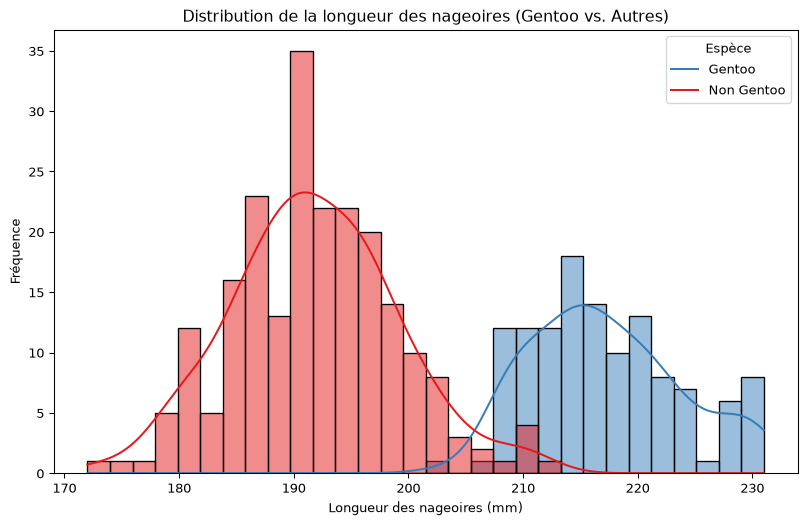

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from palmerpenguins import load_penguins
except ImportError:
    ! pip install palmerpenguins
    from palmerpenguins import load_penguins

# Charger le jeu de données Palmer Penguins
df = load_penguins()

# Ne garder que 'flipper_length_mm' et 'species'
df = df[['flipper_length_mm', 'species']]

# Supprimer les lignes avec des valeurs manquantes (NaNs)
df.dropna(inplace=True)

# Créer une étiquette binaire : 1 si Gentoo, 0 sinon
df['is_gentoo'] = (df['species'] == 'Gentoo').astype(int)

# Séparer les attributs (X) et les étiquettes (y)
X = df[['flipper_length_mm']]
y = df['is_gentoo']

# Tracer la distribution des longueurs de nageoires par étiquette d'espèce binaire
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='flipper_length_mm', hue='is_gentoo', kde=True, bins=30, palette='Set1')
plt.title('Distribution de la longueur des nageoires (Gentoo vs. Autres)')
plt.xlabel('Longueur des nageoires (mm)')
plt.ylabel('Fréquence')
plt.legend(title='Espèce', labels=['Gentoo', 'Non Gentoo'])
plt.show()

## Régression logistique (Logit)

- Malgré son nom, la **régression logistique** sert de **technique de
  classification** plutôt que de méthode de régression.

- Les **étiquettes** en régression logistique sont des valeurs binaires,
  notées $y_i \in \{0,1\}$, ce qui en fait une **tâche de classification
  binaire**.

- L’objectif principal de la régression logistique est de déterminer la
  **probabilité** qu’un exemple donné $x_i$ appartienne à la **classe
  positive**, c’est-à-dire $y_i = 1$.

La représentation des deux classes, **négative** et **positive**, par
les valeurs 0 et 1 respectivement, n’est pas arbitraire. Ce choix est
intrinsèquement lié à notre objectif de déterminer la **probabilité**
qu’une instance $x_i$ appartienne à la classe positive.

Bien que cet algorithme d’apprentissage puisse sembler peu remarquable
au départ, il est essentiel de continuer à s’y intéresser, car la
régression logistique s’avérera plus tard cruciale dans la discussion
sur les réseaux de neurones artificiels.

## Modèle

- **Cas Général :** $P(y = k | x, \theta)$, où $k$ est une étiquette de
  classe.
- **Cas Binaire :** $y \in \{0,1\}$
  - **Prédire** $P(y = 1 | x, \theta)$

## Visualiser nos données

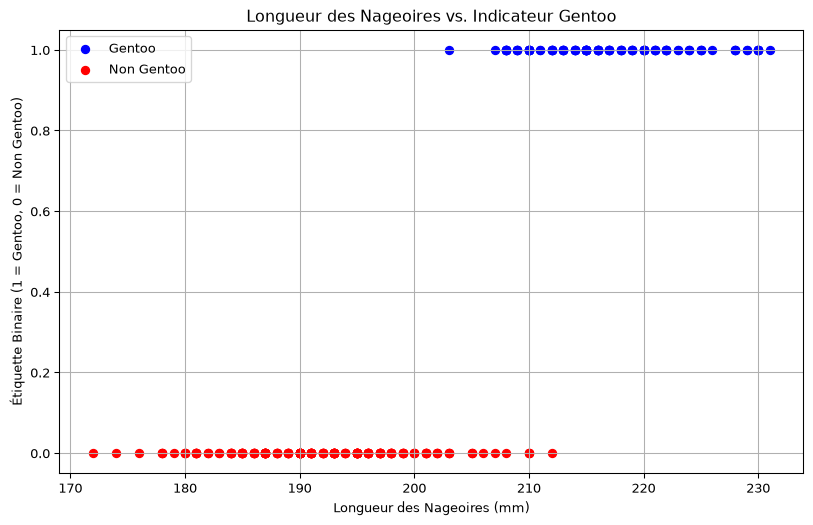

In [2]:
# Diagramme de dispersion de la longueur des nageoires vs. étiquette binaire (Gentoo ou Non Gentoo)
plt.figure(figsize=(10, 6))

# Points étiquetés comme Gentoo (is_gentoo = 1)
plt.scatter(
    df.loc[df['is_gentoo'] == 1, 'flipper_length_mm'],
    df.loc[df['is_gentoo'] == 1, 'is_gentoo'],
    color='blue',
    label='Gentoo'
)

# Points étiquetés comme Non Gentoo (is_gentoo = 0)
plt.scatter(
    df.loc[df['is_gentoo'] == 0, 'flipper_length_mm'],
    df.loc[df['is_gentoo'] == 0, 'is_gentoo'],
    color='red',
    label='Non Gentoo'
)

plt.title('Longueur des Nageoires vs. Indicateur Gentoo')
plt.xlabel('Longueur des Nageoires (mm)')
plt.ylabel('Étiquette Binaire (1 = Gentoo, 0 = Non Gentoo)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Intuition

Ajuster une régression linéaire n’est pas la solution, mais $\ldots$

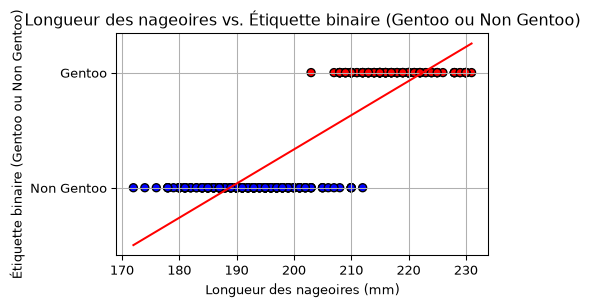

In [3]:
from sklearn.linear_model import LinearRegression
import pandas as pd

lin_reg = LinearRegression()
lin_reg.fit(X, y)

X_new = pd.DataFrame([X.min(), X.max()], columns=X.columns)

y_pred = lin_reg.predict(X_new)

# Tracer le nuage de points
plt.figure(figsize=(5, 3))
plt.scatter(X, y, c=y, cmap='bwr', edgecolor='k')
plt.plot(X_new, y_pred, "r-")
plt.xlabel('Longueur des nageoires (mm)')
plt.ylabel('Étiquette binaire (Gentoo ou Non Gentoo)')
plt.title('Longueur des nageoires vs. Étiquette binaire (Gentoo ou Non Gentoo)')
plt.yticks([0, 1], ['Non Gentoo', 'Gentoo'])
plt.grid(True)
plt.show()

## Intuition (suite)

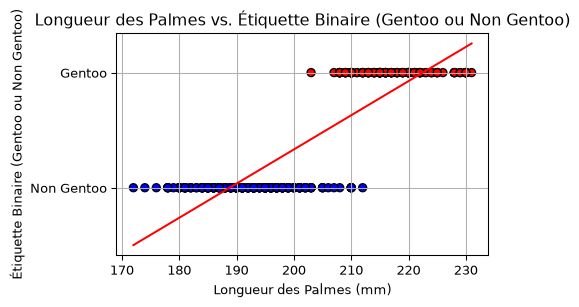

- Une haute **`flipper_length_mm`** aboutit généralement à une sortie du
  modèle proche de 1.

- Inversement, une faible **`flipper_length_mm`** produit généralement
  une sortie du modèle proche de 0.

- Notamment, les sorties du modèle ne sont pas confinées à l’intervalle
  \[0, 1\] et peuvent occasionnellement être inférieures à 0 ou dépasser
  1.

## Intuition (suite)

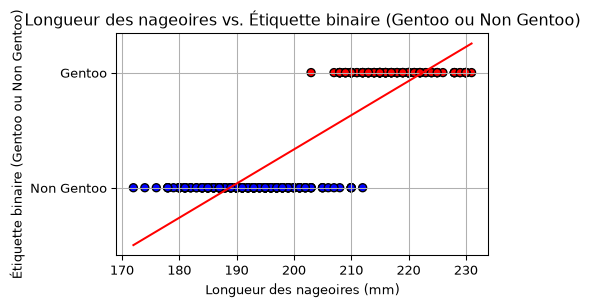

- Pour un **seul attribut**, la frontière de décision est un **point
  spécifique**.
- Dans ce cas, la **frontière de décision** est d’environ 205.

## Intuition (suite)

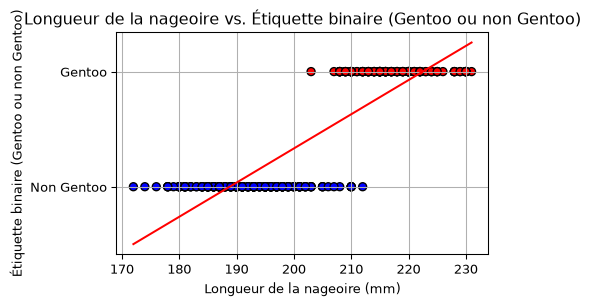

- À mesure que **`longueur_nageoire_mm`** augmente de 205 à 230, la
  confiance dans la classification de l’exemple en tant que Gentoo
  augmente.
- Inversement, à mesure que **`longueur_nageoire_mm`** diminue de 205 à
  170, la confiance dans la classification de l’exemple en tant que
  non-Gentoo augmente.

## Intuition (suite)

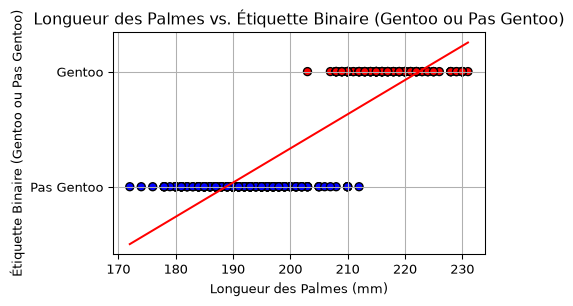

- Pour **les valeurs proches de la frontière de décision**, 205,
  certains exemples sont classés comme Gentoo tandis que d’autres ne le
  sont pas, ce qui conduit à une incertitude de classification
  comparable à un lancer de pièce (**probabilité de 0,5**).

# Fonction logistique

## Fonction logistique

La **fonction logistique standard** transforme une entrée à valeur
réelle de $\mathbb{R}$ en l’intervalle ouvert $(0,1).$ La fonction est
définie comme suit :

$$
  \sigma(t) = \frac{1}{1+e^{-t}}
$$

``` python
# Fonction Sigmoïde
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

# Générer des valeurs de t
t = np.linspace(-6, 6, 1000)

# Calculer les valeurs de y pour la fonction sigmoïde
sigma = sigmoid(t)

# Créer une figure
fig, ax = plt.subplots()
ax.plot(t, sigma, color='blue', linewidth=2)  # Garder la courbe opaque

# Tracer l'axe vertical à x = 0
ax.axvline(x=0, color='black', linewidth=1)

# Ajouter des étiquettes sur l'axe vertical
ax.set_yticks([0, 0.5, 1.0])

# Ajouter des étiquettes aux axes
ax.set_xlabel('t')
ax.set_ylabel(r'$\sigma(t)$')

plt.grid(True)
plt.show()
```

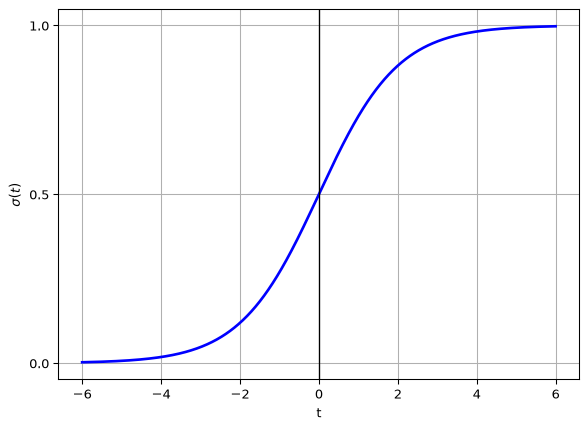

- Lorsque la variable d’entrée $t$ est égale à 0, la sortie de la
  fonction logistique est de 0,5.
  - En effet, $e^{-t} = {e^0} = 1$ et donc
    $\frac{1}{1+e^{-t}} = \frac{1}{1+1}= \frac{1}{2}.$
- À mesure que $t$ augmente, la valeur de sortie se rapproche de 1.
  - Lorsque $t \to \infty$, $e^{-t} \to 0$.
- Inversement, à mesure que $t$ devient plus négatif, la valeur de
  sortie se rapproche de 0.
  - Lorsque $t \to -\infty$, $e^{-t} \to \infty$ (les deux signes
    négatifs s’annulent).
- La fonction logistique standard est également couramment appelée
  **fonction sigmoïde**.

## Régression logistique (intuition)

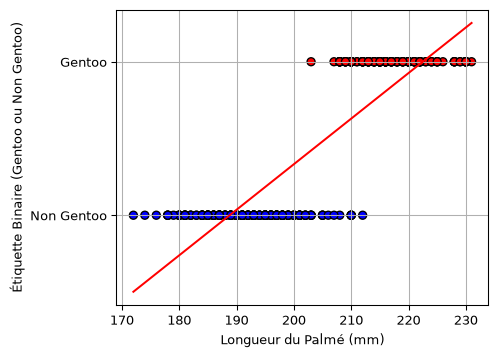

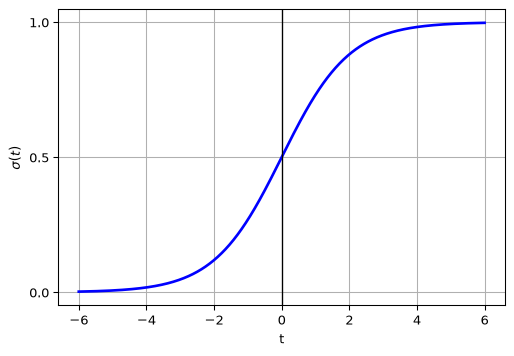

- Lorsque la **distance à la frontière de décision** est **zéro**,
  l’incertitude est élevée, rendant une probabilité de **0,5**
  appropriée.
- À mesure que nous nous **éloignons de la frontière de décision**, la
  confiance augmente, justifiant des probabilités **plus hautes** ou
  **plus basses** en conséquence.

## Fonction logistique

Une courbe en forme de S, telle que la fonction logistique standard
(également appelée **sigmoïde**), est qualifiée de **fonction
d’écrasement** (*squashing function*) car elle transforme un large
domaine d’entrée en une plage de sortie restreinte.

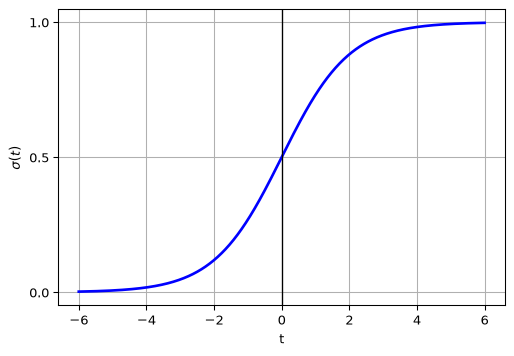

$$
  \sigma(t) = \frac{1}{1+e^{-t}}
$$

## Régression Logistique (Logit)

- De manière analogue à la **régression linéaire**, la **régression
  logistique** calcule une somme pondérée des attributs d’entrée,
  exprimée comme suit : $$
  \theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)}
  $$

- Cependant, l’utilisation de la fonction sigmoïde limite sa sortie à
  l’intervalle $(0,1)$ : $$
  \sigma(\theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

## Notation

- Equation de la **régression logistique**: $$
  \sigma(\theta_0 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

- Multipling $\theta_0$ (intercept/bias) by 1: $$
  \sigma(\theta_0 \times 1 + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

- Multipling $\theta_0$ by $x_i^{(0)} = 1$: $$
  \sigma(\theta_0 x_i^{(0)} + \theta_1 x_i^{(1)} + \theta_2 x_i^{(2)} + \ldots + \theta_D x_i^{(D)})
  $$

## Régression logistique

Le modèle de **Régression Logistique**, sous sa forme vectorisée, est
défini comme suit : $$
h_\theta(x_i) = \sigma(\theta x_i) = \frac{1}{1+e^{- \theta x_i}}
$$

Une caractéristique supplémentaire, $x_i^{(0)} = 1$, a été ajoutée à
$x_i$, et $\theta_0$ est le terme d’interception/biais.

## Régression logistique (deux attributs)

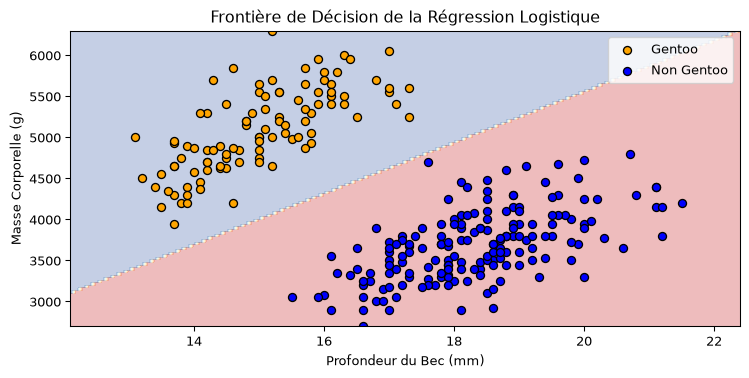

$$
  h_\theta(x_i) = \sigma(\theta x_i)
$$

- En régression logistique, **la probabilité de classer correctement un
  exemple augmente à mesure que sa distance par rapport à la frontière
  de décision augmente**.
- Ce principe est valable pour les classes **positives** et
  **négatives**.
- Un exemple situé sur la frontière de décision a une **probabilité de
  50%** d’appartenir à l’une ou l’autre des classes.

## Régression logistique

- Le modèle de **Régression Logistique**, sous sa forme vectorisée, est
  défini comme suit : $$
  h_\theta(x_i) = \sigma(\theta x_i) = \frac{1}{1+e^{- \theta x_i}}
  $$

- Les **prédictions** sont faites comme suit :

  - $y_i = 0$, si $h_\theta(x_i) < 0.5$
  - $y_i = 1$, si $h_\theta(x_i) \geq 0.5$

. . .

- Les valeurs de $\theta$ sont apprises en utilisant la **descente de
  gradient**.

------------------------------------------------------------------------

<https://youtu.be/yIYKR4sgzI8>

**Attribution** : [StatQuest: Logistic
Regression](https://youtu.be/yIYKR4sgzI8) par Josh Starmer.

“StatQuest décompose les méthodes complexes de statistiques et
d’apprentissage automatique en petites sections faciles à comprendre.
StatQuest ne simplifie pas excessivement le matériel ; au contraire, il
vous renforce pour que vous soyez plus intelligent et ayez une meilleure
compréhension des statistiques et de l’apprentissage automatique.” C’est
souvent un bon point de départ pour acquérir l’intuition nécessaire à la
compréhension des concepts statistiques et d’apprentissage automatique.

# Chiffres manuscrits

## 1989 Yann LeCun

<https://www.youtube.com/watch?v=H0oEr40YhrQ>

## Reconnaissance de chiffres manuscrits

### Objectifs :

- Développer un **modèle de régression logistique** pour la
  **reconnaissance de chiffres manuscrits**.

- Visualiser les **informations** et les **motifs** acquis par le
  modèle.

Nous utilisons les [jeux de données UCI ML de chiffres
manuscrits](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits).

## Chiffres manuscrits

Chargement du jeu de données

In [14]:
from sklearn.datasets import load_digits

digits = load_digits()

Quel est le type de `digits.data`

In [15]:
type(digits.data)

numpy.ndarray

Développement d’un **modèle de régression logistique** pour la
**reconnaissance des chiffres manuscrits** de ce jeux de données de
l’UCI ML.

## Chiffres manuscrits

Combien d’exemples (`N`) et combien d’attributs (`D`)?

In [16]:
digits.data.shape

(1797, 64)

Définition des valeurs de `N` et `D`

In [17]:
N, D = digits.data.shape

`target` a-t-il le même nombre d’entrées (exemples) que `data` ?

In [18]:
digits.target.shape

(1797,)

## Chiffres manuscrits

Quelles sont la largeur et la hauteur de ces images ?

In [19]:
digits.images.shape

(1797, 8, 8)

Définition des valeurs de `width` et `height`

In [20]:
_, width, height = digits.images.shape

## Chiffres manuscrits

Définition des valeurs de `X` et `y`

In [21]:
X = digits.data
y = digits.target

## Chiffres manuscrits

`X[0]` est un vecteur de taille `width * height = D`
($8 \times 8 = 64$).

In [22]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

. . .

Il correspond à une image de $8 \times 8 = 64$.

In [23]:
X[0].reshape(width, height)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

## Chiffres manuscrits

Afficher les `n=5` premiers exemples.

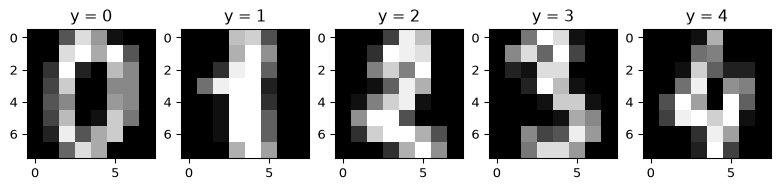

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
n = 5

for index, (image, label) in enumerate(zip(X[0:n], y[0:n])):
    plt.subplot(1, n, index + 1)
    plt.imshow(np.reshape(image, (width,width)), cmap=plt.cm.gray)
    plt.title(f'y = {label}')

Les valeurs d’intensité proches de 0 sont représentées en noir, tandis
que les valeurs élevées sont représentées en blanc.

Utiliser `cmap=plt.cm.binary` afin d’inverser les images (intensité
proches de 0 en blanc, valeurs élevées en noir).

## Chiffres manuscrits

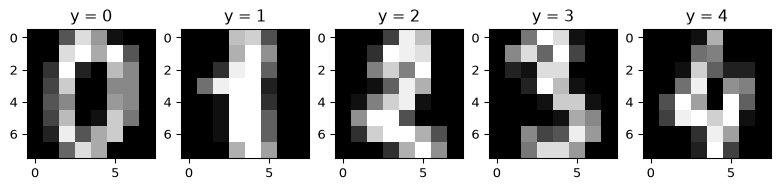

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
n = 5

for index, (image, label) in enumerate(zip(X[0:n], y[0:n])):
    plt.subplot(1, n, index + 1)
    plt.imshow(np.reshape(image, (width,width)), cmap=plt.cm.gray)
    plt.title(f'y = {label}')

- Dans notre ensemble de données, chaque $x_i$ est un **vecteur
  d’attributs** de taille $D = 64$.

- Ce vecteur est formé en concaténant les lignes d’une image de
  $8 \times 8$.

- La fonction `reshape` est utilisée pour convertir ce vecteur de 64
  dimensions en son format original d’image $8 \times 8$.

## Chiffres manuscrits

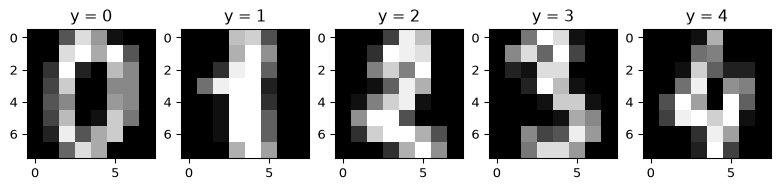

- Nous allons entraîner **10 classificateurs**, chacun correspondant à
  un chiffre spécifique dans une approche **Un-contre-Tous (OvA)**.

- Chaque classificateur déterminera les valeurs optimales des $\theta_j$
  (associées aux attributs pixels), lui permettant de distinguer un
  chiffre de tous les autres.

## Chiffres manuscrits

Préparation de notre expérience en apprentissage automatique

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## Chiffres manuscrits

Les algorithmes d’optimisation fonctionnent généralement mieux lorsque
les attributs ont des plages de valeurs similaires.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Discussion** : importance d’appliquer `fit_transform` uniquement à
`X_train`

Certains classificateurs présentent des performances sous-optimales
lorsqu’il existe des variations significatives dans les échelles des
attributs. Ce problème est particulièrement accentué dans les
classificateurs qui utilisent la descente de gradient pour
l’optimisation des paramètres, car ils peuvent être affectés
négativement par les écarts d’échelle des attributs. Par conséquent, la
standardisation des attributs est une pratique largement adoptée pour
atténuer ce problème.

[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
est une approche couramment utilisée. Pour un attribut donné, les
valeurs sont transformées comme suit :

$$
z = \frac{(x - \mu)}{\sigma}
$$

où $\mu$ est la moyenne de toutes les valeurs pour cet attribut dans les
données d’entraînement, et $\sigma$ l’écart type correspondant.

Appeler `fit` oblige le scaler à apprendre la moyenne et l’écart type de
chaque attribut. Appeler `transform` applique la transformation sur le
jeu de données désigné. Enfin, appeler `fit_transform` combine les deux
étapes.

Ce serait une erreur d’appliquer `fit` ou `fit_transform` sur l’ensemble
du jeu de données, une erreur appelée **fuite de données** (*data
leakage*). Les informations du jeu de test influenceraient la moyenne et
l’écart type appris par le scaler. Les données d’entraînement seraient
transformées en utilisant des informations biaisées par le jeu de test.
Le modèle apprendrait à partir de données d’entraînement mises à
l’échelle en utilisant des informations biaisées par le jeu de test. Le
jeu de test ne serait plus indépendant.

Il est primordial de mettre à l’échelle les données de test. Le modèle a
été entraîné sur des données mises à l’échelle, ici avec des valeurs
moyennes centrées à zéro et un écart type de 1. Les données originales
étaient probablement sur une échelle très différente. Imaginez un
attribut représentant la température en Celsius, avec des valeurs de -40
à 40. Un autre attribut, représentant une note, avec des valeurs de 0 à
100. Le modèle produirait des résultats incohérents sur de telles
données. Les données de test doivent être mises à l’échelle en utilisant
la moyenne et l’écart type des données d’entraînement, qui représentent
le cadre de référence pour son entraînement.

1.  **Équité dans l’évaluation (pas de tricherie) :** Si vous utilisez
    les données de test pour calculer la moyenne et la variance, vous
    jetez un coup d’œil aux réponses. Même si c’est “juste” une moyenne
    et un écart type, cela reste des informations provenant du jeu de
    test. Cela viole le principe selon lequel les données de test
    doivent rester complètement invisibles jusqu’à l’évaluation.

2.  **Cohérence de la distribution :** Le modèle a été entraîné en
    supposant que les attributs sont centrés et mises à l’échelle en
    utilisant la distribution d’entraînement. Si vous mettez à l’échelle
    les données de test différemment (par exemple, avec sa propre
    moyenne/écart type), alors les nombres que le modèle voit ne
    correspondent plus à la distribution sur laquelle il a été entraîné.
    C’est comme donner au modèle des entrées dans une “nouvelle langue.”

3.  **Perspective de déploiement :** Dans les applications réelles, vous
    n’aurez que la distribution d’entraînement pour calculer les
    paramètres de mise à l’échelle. Lorsque le modèle est déployé, vous
    ne pouvez pas arrêter le temps pour recalculer la mise à l’échelle
    chaque fois que de nouvelles données arrivent — vous devez appliquer
    la transformation fixe apprise à partir des données d’entraînement.

**“Le scaler fait partie du modèle.”** Tout comme les poids dans la
régression logistique, la moyenne et la variance du `StandardScaler`
sont **apprises à partir du jeu d’entraînement**. Une fois apprises,
elles deviennent des paramètres fixes de votre pipeline de
pré-traitement.

**“Entraînement vs. examen.”** Les données d’entraînement sont votre
matériel d’étude ; les données de test sont l’examen. Vous ne pouvez pas
regarder les questions de l’examen pour préparer vos notes (utiliser les
données de test pour la mise à l’échelle), et vous ne pouvez pas changer
le système de notation de l’examen à mi-chemin (mise à l’échelle des
données de test séparément). Vous devez vous préparer avec vos notes
d’étude (distribution d’entraînement) et ensuite passer l’examen dans le
même cadre.

**“La même règle pour tout le monde.”** La mise à l’échelle est comme
utiliser une règle pour mesurer des hauteurs. Vous calibrez la règle une
fois avec les données d’entraînement. Si vous utilisiez une règle
différente pour les données de test, les nombres ne seraient plus
comparables.

## Chiffres manuscrits

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression())
clf = clf.fit(X_train, y_train)

Demander au classificateur de résoudre une tâche multiclasses en
utilisant **un-contre-tous (OvR)**, aussi connu sous le nom d’OvA. Les
classificateurs dans `sklearn` ont un [support multiclasse
intégré](https://scikit-learn.org/stable/modules/multiclass.html).

Chaque régression logistique trouve un **hyperplan** dans un **espace à
64 dimensions** qui sépare les données en deux classes.

## Chiffres manuscrits

Application du classificateur à notre ensemble de test

In [30]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        17
           3       1.00      0.94      0.97        17
           4       1.00      1.00      1.00        25
           5       0.96      1.00      0.98        22
           6       1.00      1.00      1.00        19
           7       1.00      0.95      0.97        19
           8       0.80      1.00      0.89         8
           9       0.96      0.92      0.94        25

    accuracy                           0.98       180
   macro avg       0.97      0.98      0.97       180
weighted avg       0.98      0.98      0.98       180


## Visualisation

Combien de classes ?

In [31]:
clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

. . .

Les coefficients et les intercepts sont dans des tableaux distincts.

In [32]:
(clf.estimators_[0].coef_.shape, clf.estimators_[0].intercept_.shape)

((1, 64), (1,))

. . .

Les intercepts sont $\theta_0$, tandis que les coefficients sont
$\theta_j, j \in [1,64]$.

Adapté de [MNIST digits classification using Logistic regression in
Scikit-Learn](https://atmamani.github.io/projects/ml/mnist-digits-classification-using-logistic-regression-scikit-learn/),
consulté le 2024-09-23.

## Visualisation

In [33]:
clf.estimators_[0].coef_[0].round(2).reshape(width, height)

array([[ 0.  , -0.25,  0.04,  0.21,  0.02, -0.58, -0.36, -0.05],
       [ 0.  , -0.39,  0.04,  0.43,  0.53,  0.72, -0.03, -0.12],
       [-0.03,  0.19,  0.28, -0.04, -0.94,  0.84, -0.01, -0.06],
       [-0.04,  0.27,  0.26, -0.57, -1.75,  0.24,  0.07, -0.03],
       [ 0.  ,  0.32,  0.57, -0.58, -1.62, -0.15,  0.17,  0.  ],
       [-0.08, -0.13,  0.92, -0.85, -0.83, -0.01,  0.22, -0.  ],
       [-0.04, -0.36,  0.61, -0.14,  0.28,  0.01, -0.37, -0.41],
       [ 0.01, -0.31, -0.31,  0.54, -0.32, -0.18, -0.32, -0.21]])

## Visualisation

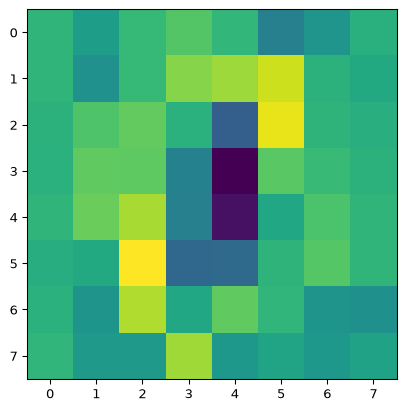

In [34]:
coef = clf.estimators_[0].coef_
plt.imshow(coef[0].reshape(width,height))

## Visualisation

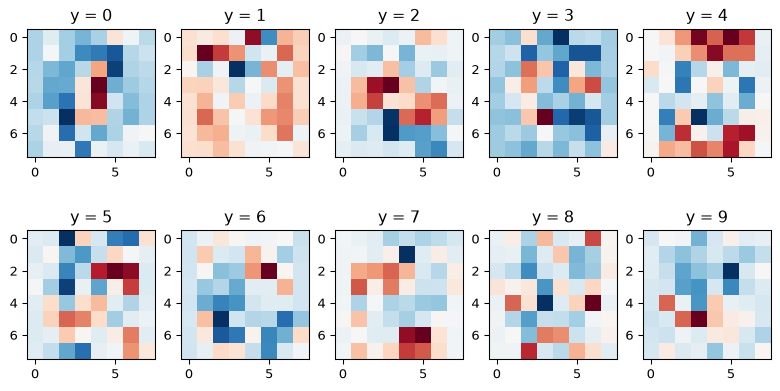

In [35]:
plt.figure(figsize=(10,5))

for index in range(len(clf.classes_)):
    plt.subplot(2, 5, index + 1)
    plt.title(f'y = {clf.classes_[index]}')
    # plt.imshow(clf.coef_[index].reshape(width,width), 
    plt.imshow(clf.estimators_[index].coef_.reshape(width,width), 
               cmap=plt.cm.RdBu)

Chaque `LogisticRegression` apprend `D=64` paramètres $\theta_j$.

Dans les images ci-dessus, les pixels rouges correspondent à des
coefficients négatifs, tandis que les pixels bleus correspondent à des
coefficients positifs.

Pour le premier classificateur, qui prédit le chiffre ‘0’, le modèle
attribue des poids négatifs aux pixels de haute intensité au centre de
l’image et des poids positifs aux pixels de haute intensité dans la
région ovale entourant le centre.

## Visualisation

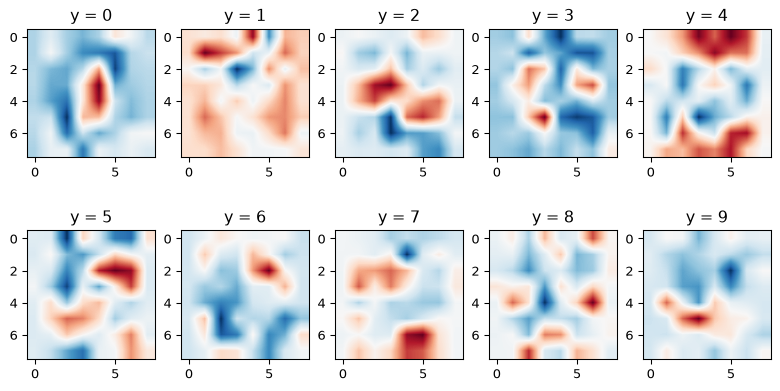

In [36]:
plt.figure(figsize=(10,5))

for index in range(len(clf.classes_)):
    plt.subplot(2, 5, index + 1)
    plt.title(f'y = {clf.classes_[index]}')
    # plt.imshow(clf.coef_[index].reshape(width,width), 
    plt.imshow(clf.estimators_[index].coef_.reshape(width,width), 
               cmap=plt.cm.RdBu,
               interpolation='bilinear')

------------------------------------------------------------------------

<https://youtu.be/AX-ZEC-71DI>

**Attribution**: [Machine Learning and Logistic
Regression](https://youtu.be/AX-ZEC-71DI), IBM Technology, 2024-07-19.

# Prologue

## Références

Alharbi, Fadi, et Aleksandar Vakanski. 2023. « Machine Learning Methods
for Cancer Classification Using Gene Expression Data: A Review ».
*Bioengineering* 10 (2): 173.
<https://doi.org/10.3390/bioengineering10020173>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Wu, Qianfan, Adel Boueiz, Alican Bozkurt, et al. 2018. « [Deep Learning
Methods for Predicting Disease Status Using Genomic
Data](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6530791) ». *Journal
of biometrics & biostatistics* 9 (5).

## Ressource

- [Logistic Regression 3-class
  Classifier](https://scikit-learn.org/stable/auto_examples/linear_model/plot_iris_logistic.html)
  par `sklearn`

## Prochain cours

- Évaluation croisée et mesures de performance

# Annexe

## Un-contre-Tous (complet)

``` python
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Binarize the output
y_bin = label_binarize(y, classes=[0, 1, 2])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)
```

## Un-contre-Tous (complet)

In [38]:
# Train a One-vs-All classifier for each class

classifiers = []
for i in range(3):
    clf = LogisticRegression()
    clf.fit(X_train, y_train[:, i])
    classifiers.append(clf)

Chaque régression logistique trouve un **hyperplan** dans un **espace à
4 dimensions** qui sépare les données en deux classes.

## Un-contre-Tous (complet)

In [39]:
# Predict on a new sample
new_sample = X_test[0].reshape(1, -1)

confidences = [clf.decision_function(new_sample) for clf in classifiers]

# Final assignment
final_class = np.argmax(confidences)

# Printing the result
print(f"Final class assigned: {iris.target_names[final_class]}")
print(f"True class: {iris.target_names[np.argmax(y_test[0])]}")

Final class assigned: versicolor
True class: versicolor

## `label_binarized`

In [40]:
from sklearn.preprocessing import label_binarize
from pprint import pprint

# Original class labels
y_train = np.array([0, 1, 2, 0, 1, 2, 1, 0])

# Binarize the labels
y_train_binarized = label_binarize(y_train, classes=[0, 1, 2])

# Assume y_train_binarized contains the binarized labels
print("Binarized labels:\n", y_train_binarized)

# Convert binarized labels back to the original numerical values
original_labels = [np.argmax(b) for b in y_train_binarized]
print("Original labels:\n", original_labels)

Binarized labels:
 [[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]]
Original labels:
 [np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0)]

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa

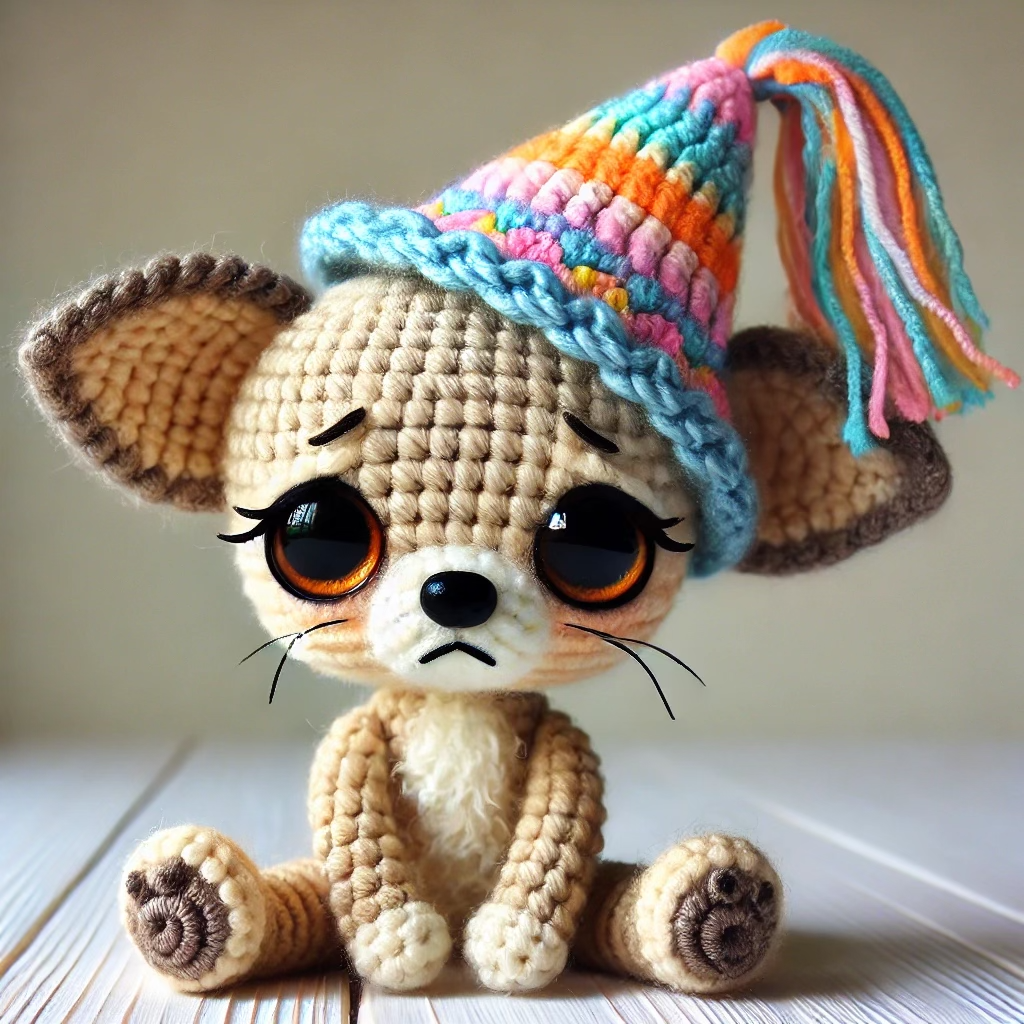

**Attribution**: “An image of a sad Chihuahua amigurumi with a birthday
hat.” Générée par DALL-E, via ChatGPT (GPT-4), OpenAI, 16 septembre,
2024.